In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [45]:
df = pd.read_csv("cardio_train.csv", sep=";")
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [29]:
df.drop("id", axis=1, inplace=True)
df["age"] = (df["age"] / 365).round(1)

print("Rows before cleaning:", len(df))

df = df[(df["ap_hi"] >= 80) & (df["ap_hi"] <= 250)]
df = df[(df["ap_lo"] >= 40) & (df["ap_lo"] <= 200)]
df = df[df["ap_hi"] > df["ap_lo"]]

for col in ["height", "weight"]:
    low, high = df[col].quantile([0.005, 0.995])
    df = df[(df[col] >= low) & (df[col] <= high)]

print("Rows after cleaning:", len(df))

Rows before cleaning: 70000
Rows after cleaning: 67539


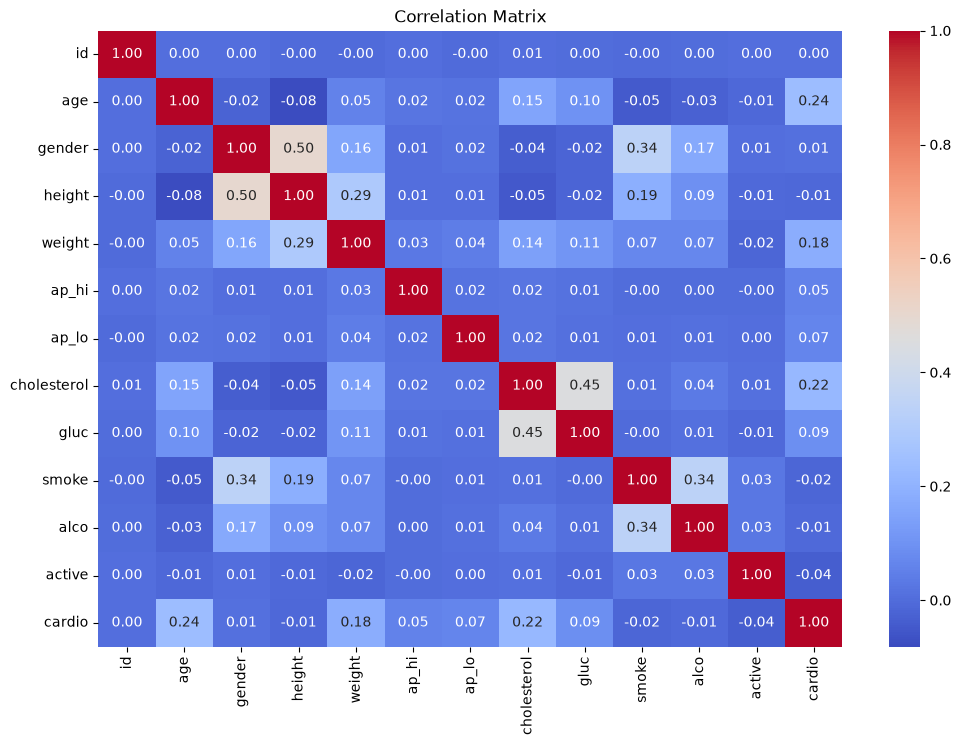

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

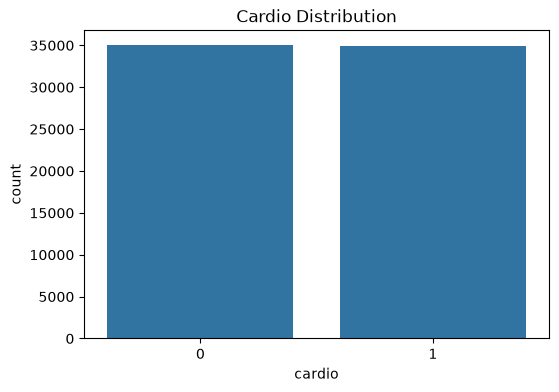

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x="cardio", data=df)
plt.title("cardio Distribution")
plt.show()

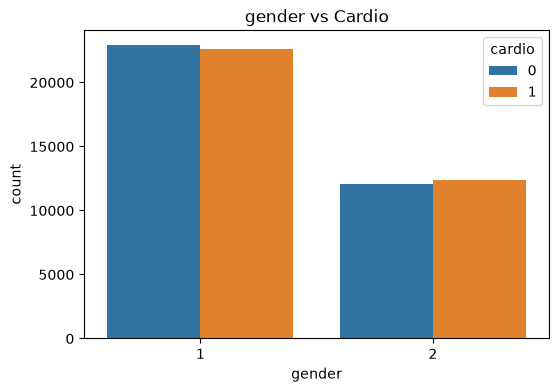

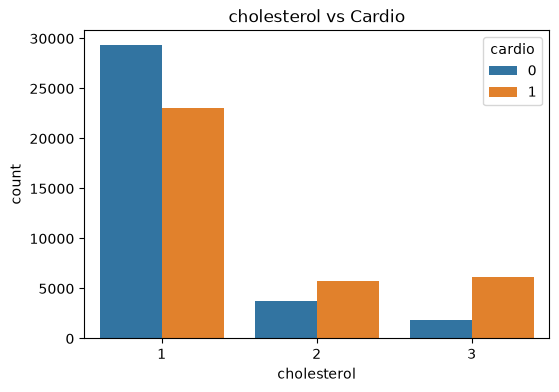

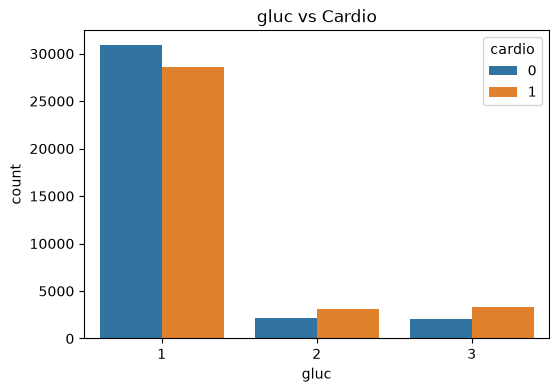

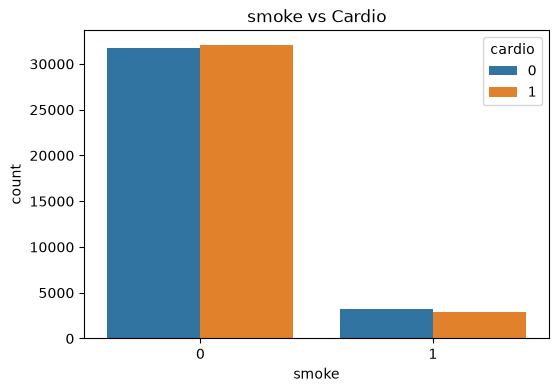

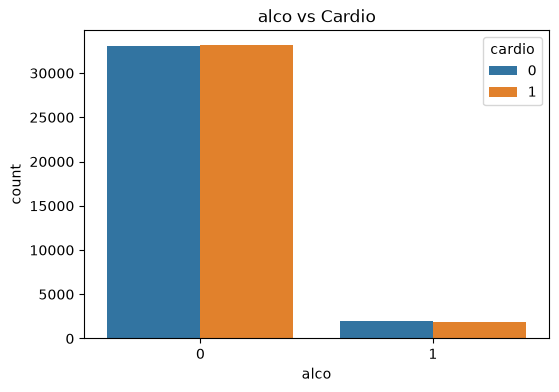

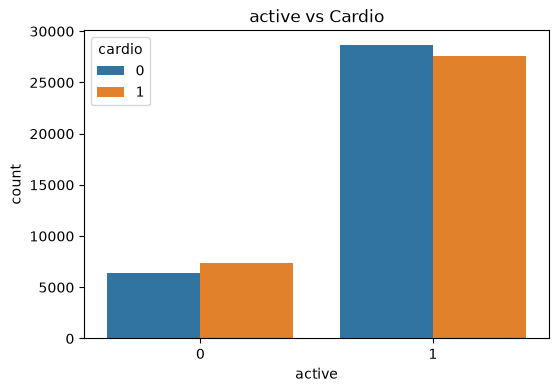

In [ ]:
categorical_cols = ["gender", "cholesterol", "gluc", "smoke", "alco", "active"]

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, hue="cardio", data=df)
    plt.title(f"{col} vs cardio")
    plt.show()

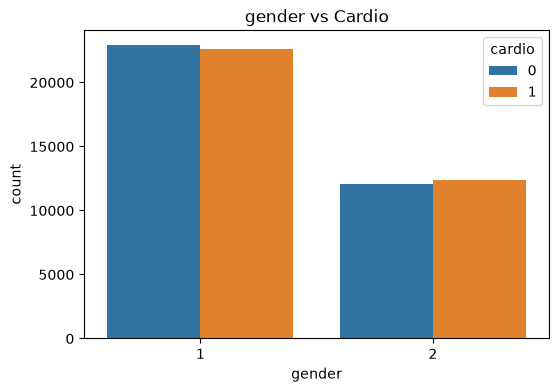

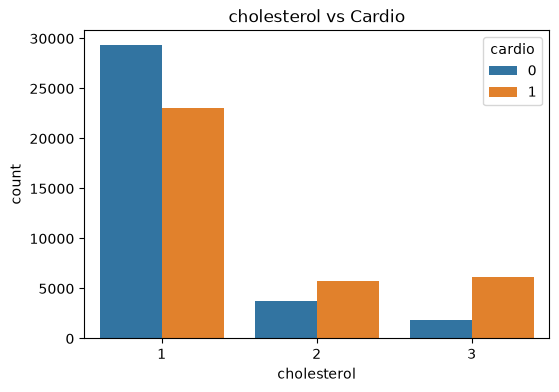

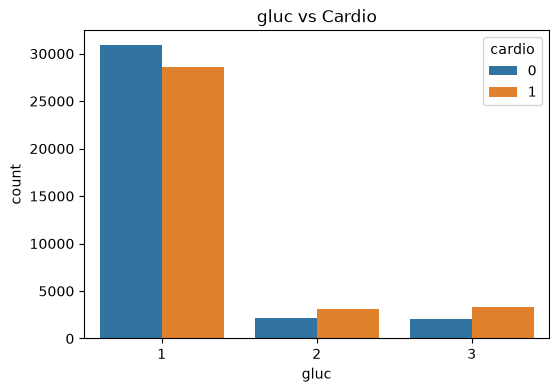

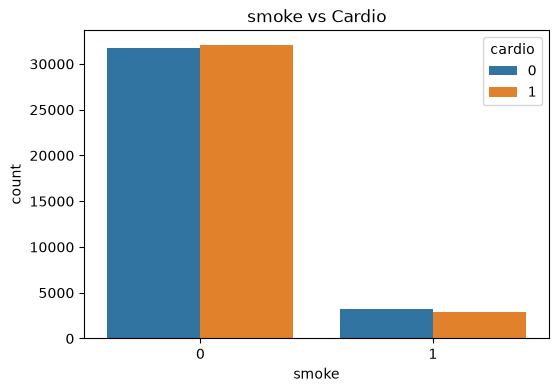

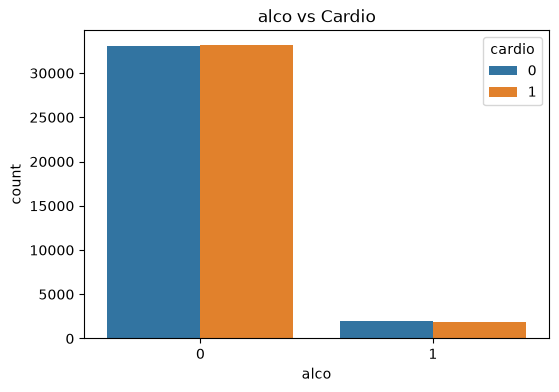

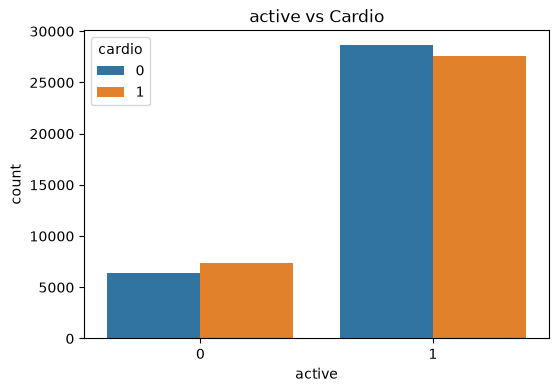

In [ ]:
categorical_cols = ["gender", "cholesterol", "gluc", "smoke", "alco", "active"]

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, hue="cardio", data=df)
    plt.title(f"{col} vs cardio")
    plt.show()

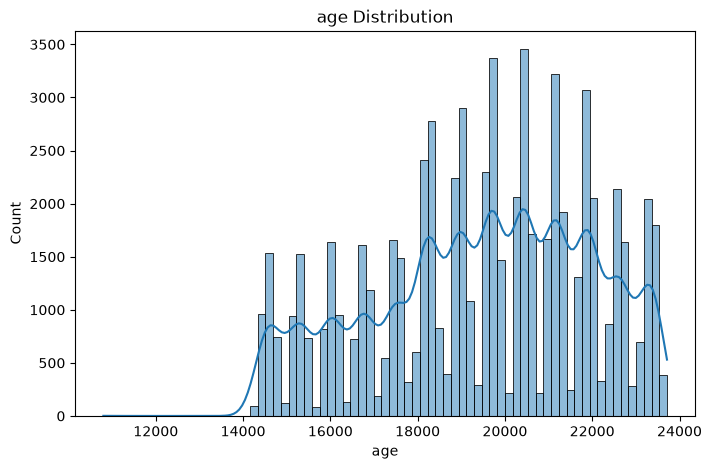

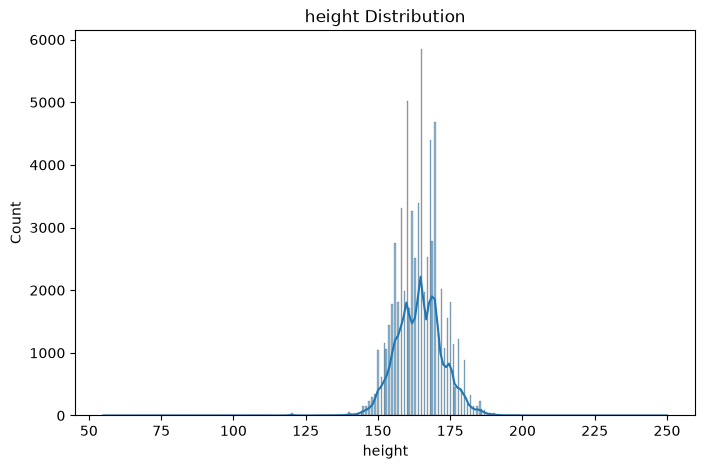

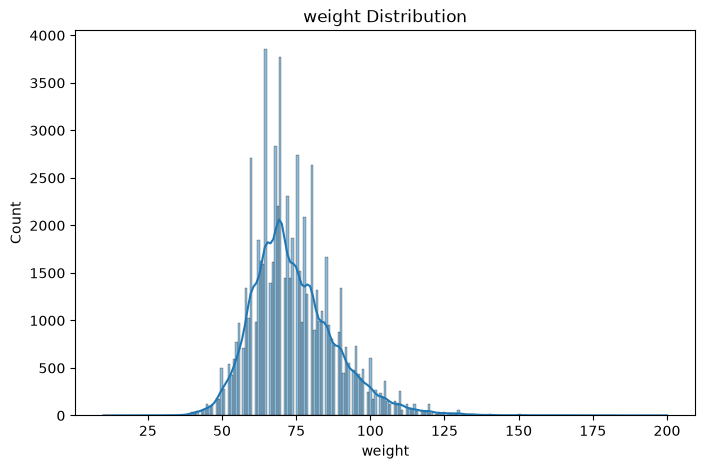

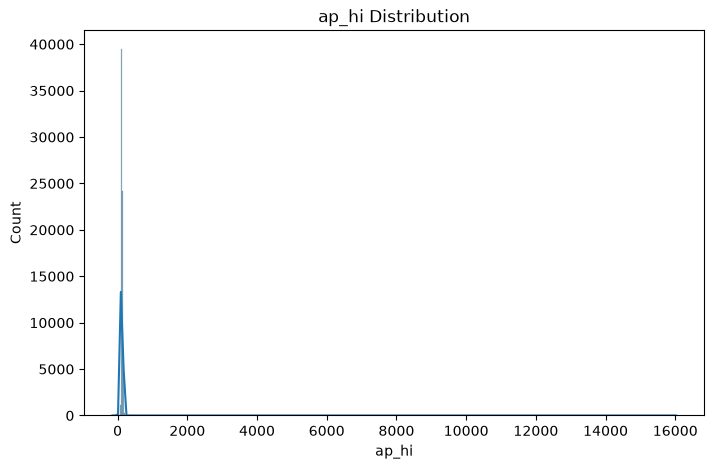

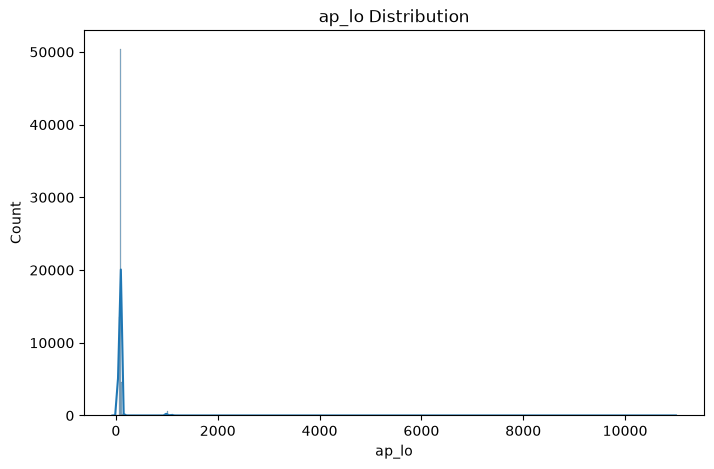

In [ ]:
numeric_cols = ["age", "height", "weight", "ap_hi", "ap_lo"]

for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

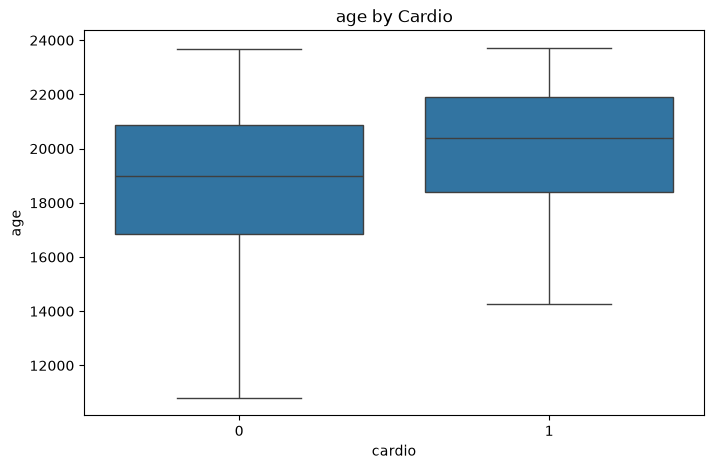

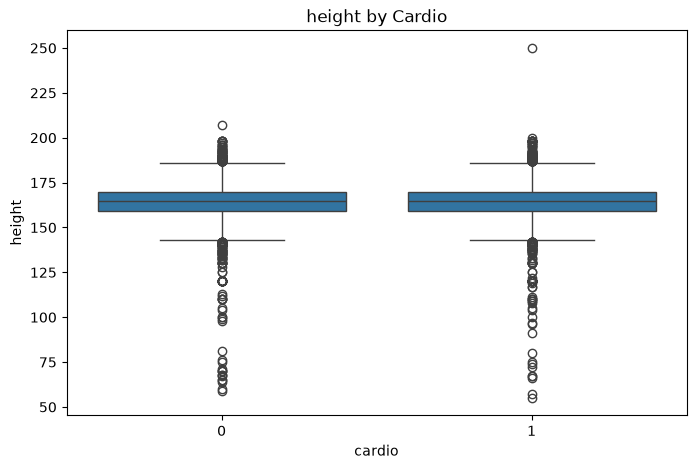

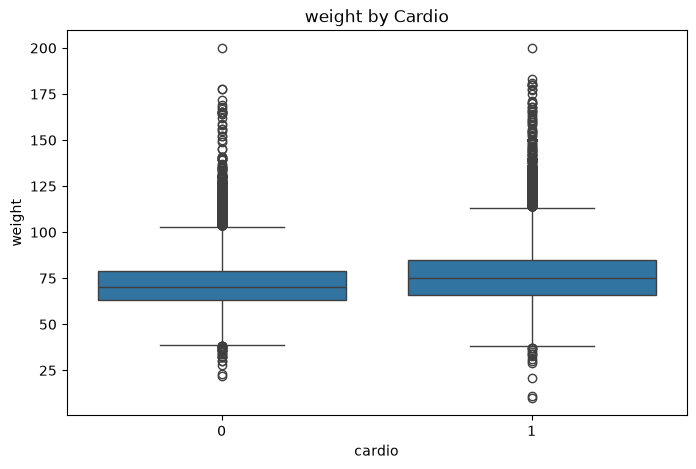

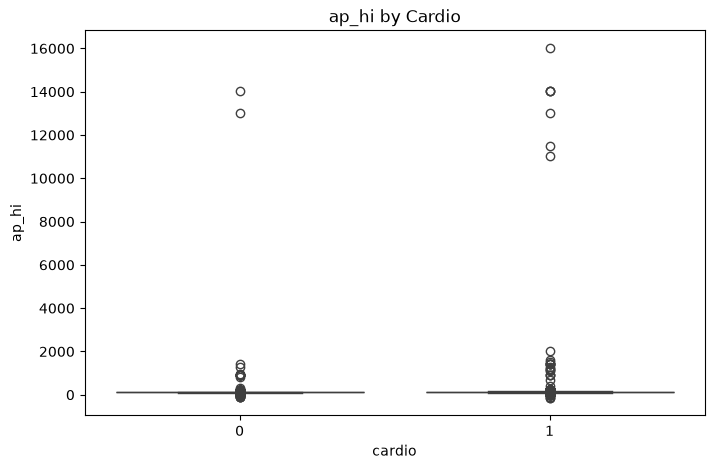

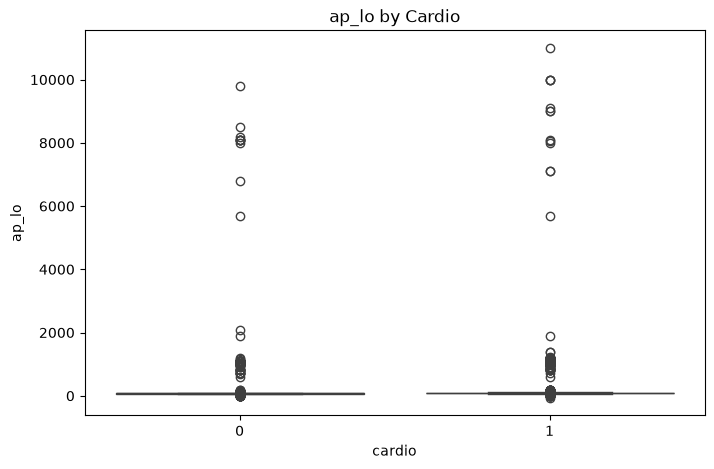

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x="cardio", y=col, data=df)
    plt.title(f"{col} by cardio")
    plt.show()

In [ ]:
X = df.drop("cardio", axis=1)
y = df["cardio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(kernel="linear")
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = accuracy_score(y_test, y_pred)

results_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": list(results.values())
})
results_df = results_df.sort_values(by="Accuracy", ascending=False)
print(results_df)

                 Model  Accuracy
0  Logistic Regression  0.722313
4                  SVM  0.721943
3        Random Forest  0.704545
1                  KNN  0.688925
2        Decision Tree  0.628813


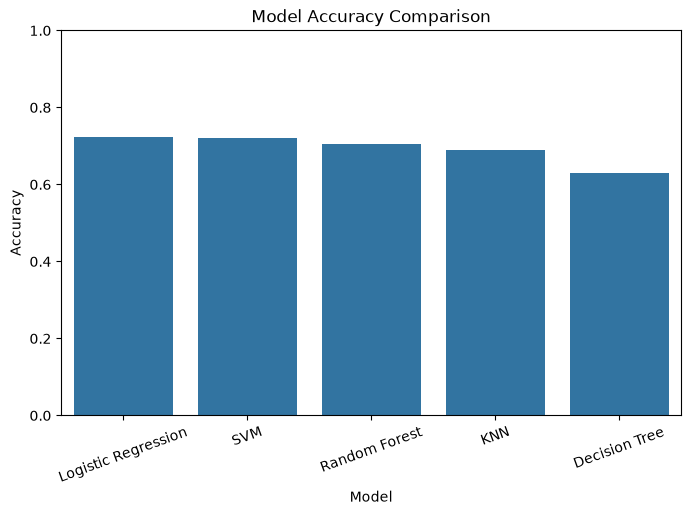

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Model", y="Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.show()

In [39]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("Best Model:", best_model_name)
print("Accuracy:", results[best_model_name])

Best Model: Logistic Regression
Accuracy: 0.7223127035830619
